## EDA: 心臓病予測チャレンジ
このノートブックでは、糖尿病予測チャレンジのデータを探索的に分析します。

In [1]:
import sys

sys.path.append("../utils")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import Ridge, Lasso
from scipy.stats import skew
from scipy.special import boxcox1p 
import lightgbm as lgb
import xgboost as xgb
import catboost as cb
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings("ignore")

from utils import check_df

In [2]:
# データ読み込み
class Paths:
    p = "/Users/shirokoshikentaro/Desktop/Predicting Heart Disease/Data"
    train = p + "/train.csv"
    test = p + "/test.csv"
    sample = p + "/sample_submission.csv"

In [3]:
train = pd.read_csv(Paths.train)
test = pd.read_csv(Paths.test)

# 元のデータのobject型の列を確認（reduce_mem_usage実行前）
print("元のデータのobject型の列:")
print(train.select_dtypes(include=["object"]).columns.tolist())

元のデータのobject型の列:
['Heart Disease']


In [4]:
def reduce_mem_usage(df):
    start_mem = df.memory_usage().sum() / 1024**2
    print('Memory usage of dataframe is {:.2f} MB'.format(start_mem))

    for col in df.columns:
        col_type = df[col].dtype

        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
        else:
            df[col] = df[col].astype('category')

    end_mem = df.memory_usage().sum() / 1024**2
    print('Memory usage after optimization is: {:.2f} MB'.format(end_mem))
    print('Decreased by {:.1f}%'.format(100 * (start_mem - end_mem) / start_mem))

    return df

In [5]:
train = reduce_mem_usage(train)

Memory usage of dataframe is 72.10 MB
Memory usage after optimization is: 13.22 MB
Decreased by 81.7%


In [6]:
check_df(train)

,Column,dtypes,NaN Count,Nunique,Unique Values
0,id,int32,0,630000,> 10 unique values
1,Age,int8,0,42,> 10 unique values
2,Sex,int8,0,2,"[1, 0]"
3,Chest pain type,int8,0,4,"[4, 1, 2, 3]"
4,BP,int16,0,66,> 10 unique values
5,Cholesterol,int16,0,150,> 10 unique values
6,FBS over 120,int8,0,2,"[0, 1]"
7,EKG results,int8,0,3,"[0, 2, 1]"
8,Max HR,int16,0,93,> 10 unique values
9,Exercise angina,int8,0,2,"[1, 0]"


In [7]:
print(f"train shape: {train.shape}")
print(f"test shape: {test.shape}")

train shape: (630000, 15)
test shape: (270000, 14)


In [11]:
# 数値型の列を取得
num_features = train.select_dtypes(include=[np.number]).columns.tolist()
num_features.remove("id")
# num_features.remove("Heart Disease")
num_features


['Age',
 'Sex',
 'Chest pain type',
 'BP',
 'Cholesterol',
 'FBS over 120',
 'EKG results',
 'Max HR',
 'Exercise angina',
 'ST depression',
 'Slope of ST',
 'Number of vessels fluro',
 'Thallium']

In [10]:
# カテゴリカル変数を抽出（object型とcategory型の両方を含む）
# reduce_mem_usageでobject型がcategory型に変換されているため、両方を含める
cat_features = train.select_dtypes(include=["object", "category"]).columns.tolist()
cat_features

['Heart Disease']

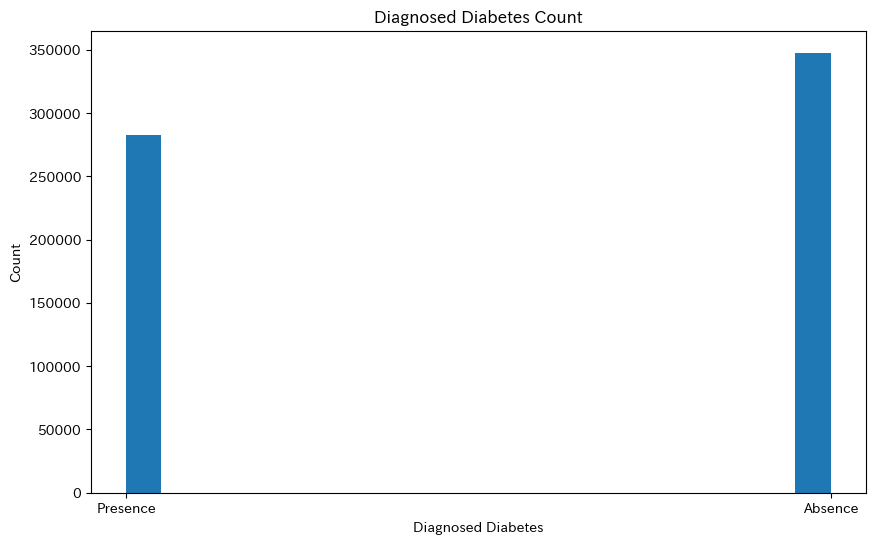

In [12]:
target_col = "Heart Disease"

plt.figure(figsize=(10, 6))
plt.title("Diagnosed Diabetes Count")
plt.hist(train[target_col],bins=20)
plt.xlabel("Diagnosed Diabetes")
plt.ylabel("Count")
plt.show()

TypeError: ufunc 'divide' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

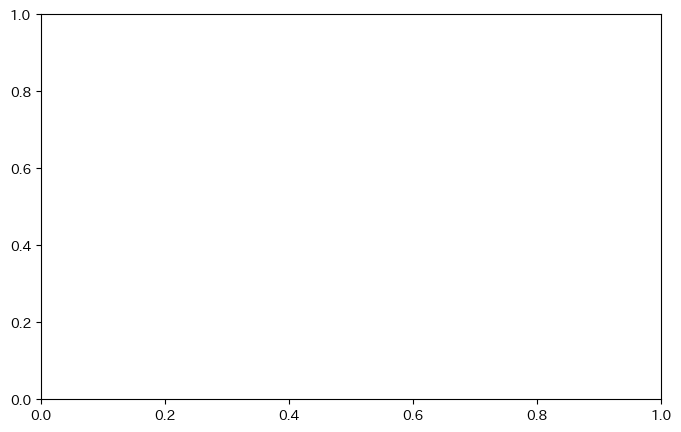

In [13]:
plt.figure(figsize=(8, 5))
plt.boxplot(train[target_col])
plt.grid()
plt.show()